In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0-rc0


In [11]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


In [6]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [7]:
# Build Artificial Neural Network

model = Sequential()

# Input + First Hidden Layer
model.add(Dense(
    16,
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

# Second Hidden Layer
model.add(Dense(
    8,
    activation='relu'
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

model.summary()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile ANN Model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [12]:
# Early stopping to prevent overfitting

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Early stopping configured")

Early stopping configured


In [13]:
# Train the ANN Model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3654 - loss: 0.9571 - val_accuracy: 0.4176 - val_loss: 0.8125
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3791 - loss: 0.7767 - val_accuracy: 0.5165 - val_loss: 0.6836
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5522 - loss: 0.6599 - val_accuracy: 0.6264 - val_loss: 0.5989
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7610 - loss: 0.5779 - val_accuracy: 0.7912 - val_loss: 0.5353
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8571 - loss: 0.5094 - val_accuracy: 0.8462 - val_loss: 0.4805
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8874 - loss: 0.4494 - val_accuracy: 0.8681 - val_loss: 0.4311
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8956 - loss: 0.3962 - val_accuracy: 0.8791 - val_loss: 0.3854
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9121 - loss: 0.3482 - val_accuracy: 0.

In [14]:
# Generate Predictions

y_pred_prob = model.predict(X_test_scaled)

# Convert probabilities into classes
y_pred = (y_pred_prob > 0.5).astype(int)

print("Prediction completed")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediction completed


In [15]:
# Model Accuracy

ann_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("ANN Test Accuracy:", ann_accuracy)

ANN Test Accuracy: 0.956140350877193


In [16]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[40  2]
 [ 3 69]]


In [17]:
# Classification Report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



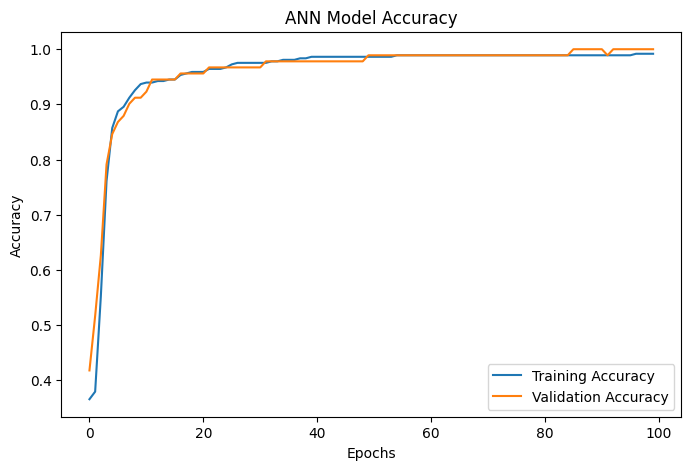

In [18]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ANN Model Accuracy")

plt.legend()
plt.show()

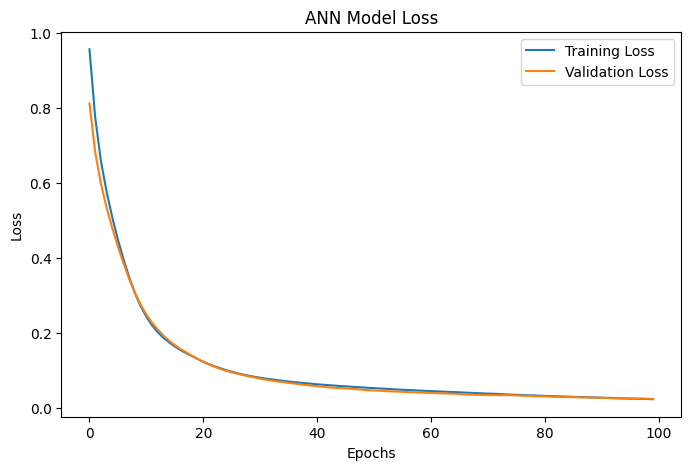

In [19]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Model Loss")

plt.legend()
plt.show()

In [20]:
# Save ANN Model

model.save("ann_breast_cancer_model.h5")

print("Model saved successfully")

Model saved successfully


In [27]:
import joblib

joblib.dump(
    scaler,
    "breast_cancer_scaler.pkl"
)

print("Scaler saved successfully")

# Save feature names
joblib.dump(
    list(X.columns),
    "feature_names.pkl"
)

print("Scaler and feature names saved successfully")

Scaler saved successfully
Scaler and feature names saved successfully


In [21]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Artificial Neural Network"
    ],
    "Accuracy": [
        0.9824,   # Task 5 Logistic Regression result
        0.9649,   # Task 5 Random Forest result
        0.9649,   # Task 5 Gradient Boosting result
        ann_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.98240
1,Random Forest,0.96490
2,Gradient Boosting,0.96490
3,Artificial Neural Network,0.95614


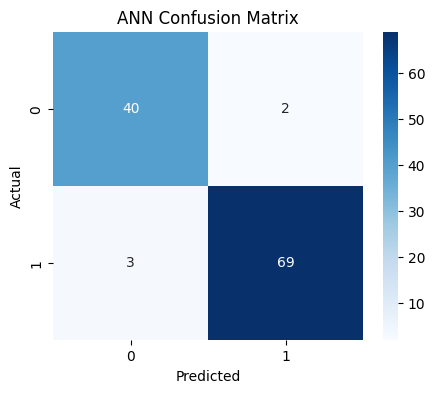

In [25]:
import seaborn as sns

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()

## CONCLUSION

In this project, an Artificial Neural Network was developed using TensorFlow and Keras for breast cancer classification. The model was trained using scaled features and evaluated using accuracy, confusion matrix, and classification metrics. Early stopping was applied to reduce overfitting. The ANN successfully learned complex patterns from the dataset and demonstrated the capability of deep learning approaches for binary classification problems.